# Grids of SNEC models
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [1]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import SNEC_output_parser, plot_vel_radius_at_time_t, plot_mass_radius, plot_v_radius_time, get_times, sci_to_latex, plot_LC
import astropy.units as u
import glob
from itertools import cycle
%load_ext autoreload
%autoreload 2

Hardcoded some constants


In [2]:
def get_energy_from_folder(folder):
    return float(folder.split("_e_")[-1].rstrip("/").replace("d", "e"))

In [3]:
root = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models = sorted(glob.glob(root+"*.*/"), key=get_energy_from_folder)
print(models)
print(len(models))
BE = 0.64589366106874414e51 *u.erg # see Table 2 in Morozova et al. 2015

['/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.0d0/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.25d51/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.5d51/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.75d51/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d51/']
5


In [4]:
tmax = 24*u.h

/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.0d0/
/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.25d51/
/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.5d51/
/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.75d51/
/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d51/


Text(0, 0.5, 'radius [cm]')

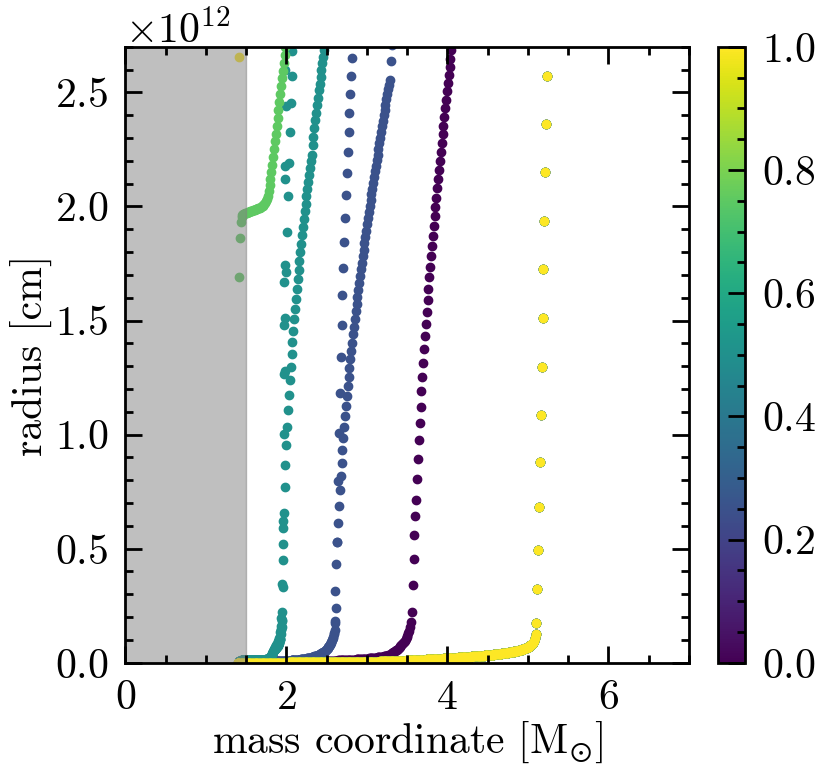

In [19]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

bomb_spread = 0.1 *u.Msun #  see parameters file
colors = plt.cm.viridis(np.linspace(0,1,len(models)))

for j, m in enumerate(models):
    print(m)
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times):
            m, r, p = plot_mass_radius(t, outfile, ax=ax, # alpha=0.5, # s=10*(1+i),
                                       c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.to(u.h).value)
            xmin = min(m).to(u.Msun).value
            if t >= tmax: break
    except:
        print("FAILED")
        pass
plt.colorbar(p, cax=cax)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")
ax.axvspan(xmin=0, xmax=xmin+bomb_spread.to(u.Msun).value, alpha=0.5, color="#808080")
ax.set_xlim(0, 7.0)
# ax.set_yscale('log')
ax.set_ylim(-1, 2.7e12)

ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$")

/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.0d0/
0.0 s 24.0 h
360.0664689737209 s 24.0 h
720.0601799645829 s 24.0 h
/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.25d51/
0.0 s 24.0 h
360.2591877741872 s 24.0 h
720.3106136806891 s 24.0 h
1080.2289718306056 s 24.0 h
1440.2816180073883 s 24.0 h
1800.213348588408 s 24.0 h
2160.246260754406 s 24.0 h
2520.252725923596 s 24.0 h
/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.5d51/
0.0 s 24.0 h
361.73432341684804 s 24.0 h
722.4016797312767 s 24.0 h


1081.0604355675412 s 24.0 h
1440.8006025810882 s 24.0 h
1801.0223107856482 s 24.0 h
2162.4194665052833 s 24.0 h
2521.0620310176178 s 24.0 h
2881.1794945453576 s 24.0 h


3241.440392855152 s 24.0 h
3600.9046117780135 s 24.0 h
3960.81496210432 s 24.0 h
4321.505823952835 s 24.0 h
4681.148810060613 s 24.0 h
5041.283744857745 s 24.0 h


5400.944616635082 s 24.0 h
5761.611726835897 s 24.0 h
6121.3435440371195 s 24.0 h
6481.400151151268 s 24.0 h
6841.396152336165 s 24.0 h
7201.507525381804 s 24.0 h


7560.812112215134 s 24.0 h
7921.249013714655 s 24.0 h
8281.324707719756 s 24.0 h
8641.536239466888 s 24.0 h


...

12602.825945638315 s 24.0 h
12964.400280264548 s 24.0 h
13324.78379597901 s 24.0 h
13684.099370991673 s 24.0 h


14044.511524768595 s 24.0 h
14404.690161893419 s 24.0 h
14764.649963729526 s 24.0 h
15125.0290989072 s 24.0 h


15485.10403762049 s 24.0 h
15843.914649870077 s 24.0 h
16202.849020367812 s 24.0 h


16562.732822883485 s 24.0 h
16922.861636643895 s 24.0 h
17280.0 s 24.0 h


(-1000.0, 1000.0)

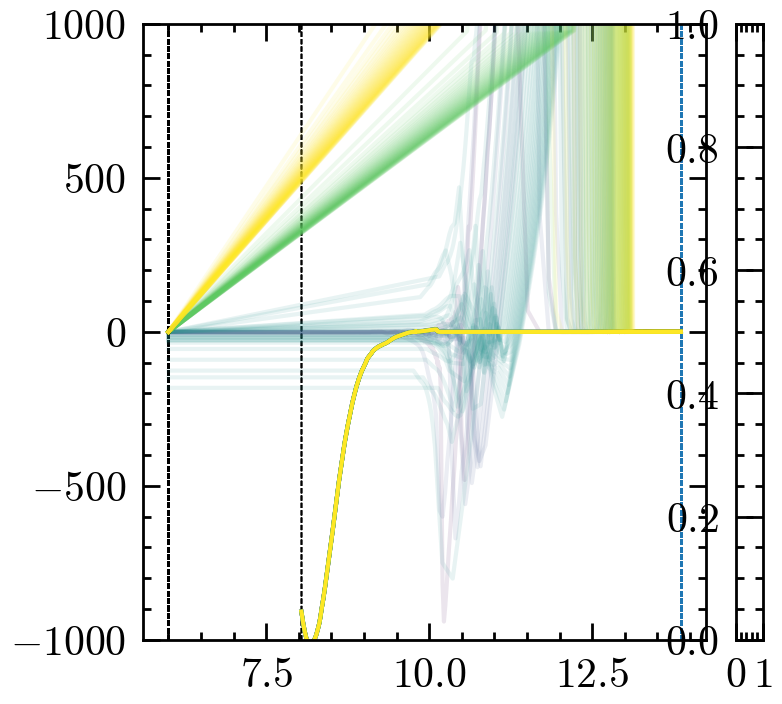

In [36]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

for j, m in enumerate(models):
    print(m)
    # try:
    times = get_times(m+'Data/mass.xg')
    for i, t in enumerate(times):
        # print(t, tmax)
        if t.to(u.d) >= tmax.to(u.d): break
        plot_v_radius_time(t, m+'/Data/vel.xg', m+'/Data/mass.xg', ax=ax, c=colors[j], alpha=max(0.1,1-min(0.9, t.value/tmax.value)))
    
ax.set_ylim(-1000, 1000)

In [ ]:
fig = plt.figure(figsize=(15,20))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*.*/"), key=get_energy_from_folder)
# print(len(models15), models15)
for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times):
            # print(t.to(u.h))
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
            xmin = min(m.to(u.Msun))               
    except:
        print("FAILED")
        pass

s30 = "/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/"
models30 = sorted(glob.glob(s30+"*.*/"), key=get_energy_from_folder)
# print(len(models30), models30)
for j, m in enumerate(models30):
    ax = axes[2*j+1]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        for i, t in enumerate(times):
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
            
    except:
        print("FAILED")
        pass
xmin = min(m.to(u.Msun))
plt.colorbar(p, cax=cax)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")

for i, ax in enumerate(axes):
    # ax.set_xlim(0, 5.0)
    ax.set_yscale('log')
    if (i%2 !=0): ax.set_yticklabels([])
    if (i != 16) and (i !=17): ax.set_xticklabels([])
    
axes[0].set_title(r"$15M_{\odot}$ RSG", size=30)
axes[1].set_title(r"$30M_{\odot}$ WR", size=30)
axes[16].set_xlabel(r"mass coordinate [$M_{\odot}$]")
axes[17].set_xlabel(r"mass coordinate [$M_{\odot}$]")
cax.set_ylabel(r"time [h]")
# ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
# ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$") 

In [ ]:
fig = plt.figure(figsize=(20,30))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*/*.*/"), key=get_energy_from_folder)

for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        vel_file = m+'Data/vel.xg'
        mass_file = m+'Data/mass.xg'
        times = get_times(vel_file)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times[::10]):           
            m, r, p = plot_v_radius_time(t, vel_file, mass_file,
                                         ax=ax, alpha=0.5, # s=10*(1+i),
                                         # c=colors[j],
                                         # ls = linestyles[j],
                                         label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=240)
            xmin = min(m.to(u.Msun))
    except:
        print("FAILED")
        pass


/home/mrenzo/Documents/Research/codes/SNEC-1.01/scripts/plot_aux.py:415: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


Text(0, 0.5, '$\\log_{10}(L/\\mathrm{[erg\\ s^{-1}]})$')

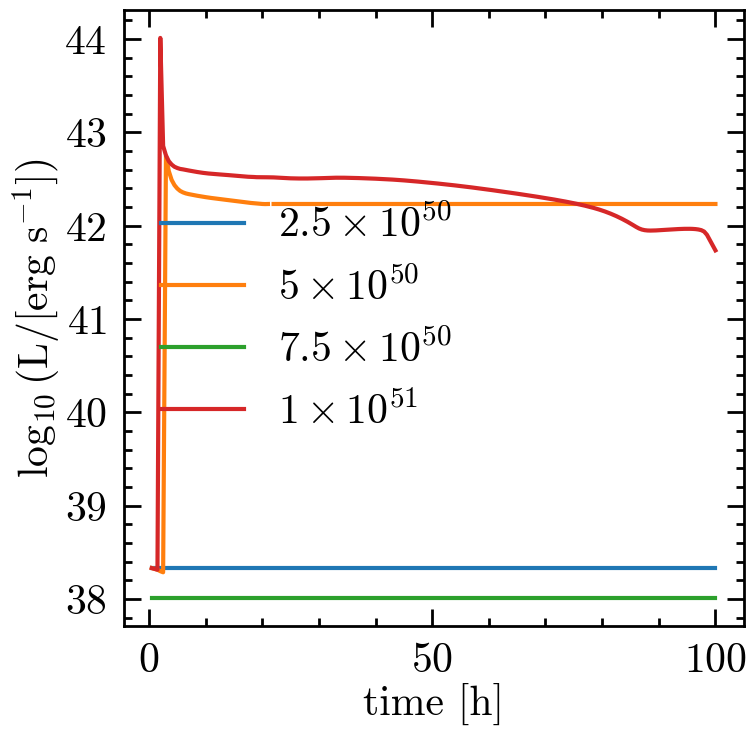

In [32]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for m in sorted(glob.glob(root+'/test/*.*/'), key=get_energy_from_folder):
    # try:
    fname = m+'/Data/lum_observed.dat'
    plot_LC(fname, ax=ax, label=sci_to_latex(get_energy_from_folder(m)))
    # except: # IndexError:
    #     pass
    #    print(m, "failed")
    
ax.legend()
ax.set_xlabel(r"time [h]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{[erg\ s^{-1}]})$")

In [29]:
# sorted(glob.glob(root+'/test/*.*/'), key=get_energy_from_folder)

['/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor//test/bomb_final_e_0.25d51/',
 '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor//test/bomb_final_e_0.5d51/',
 '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor//test/bomb_final_e_0.75d51/',
 '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor//test/bomb_final_e_1.0d51/']